# Proximal Policy Optimization  
  ref : https://keras.io/examples/rl/ppo_cartpole/  

In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

In [3]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import scipy.signal
import time

## Functions and class

* Buffer Class

In [4]:
## 감가된 누적 합 Gt
def discounted_cumulative_sums(x, discount):
    result = np.zeros_like(x, dtype=np.float64)
    running_sum = 0
    for t in reversed(range(len(x))):
        running_sum = x[t] + discount * running_sum
        result[t] = running_sum
    return result

class Buffer:
    # Buffer for storing trajectories
    def __init__(self, state_dimensions, size, gamma=0.99, lam=0.95):
        # Buffer initialization
        self.state_buffer = np.zeros((size, state_dimensions), dtype=np.float32)
        self.action_buffer = np.zeros(size, dtype=np.int32)
        self.advantage_buffer = np.zeros(size, dtype=np.float32)
        self.reward_buffer = np.zeros(size, dtype=np.float32)
        self.return_buffer = np.zeros(size, dtype=np.float32)
        self.value_buffer = np.zeros(size, dtype=np.float32)
        self.logprobability_buffer = np.zeros(size, dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.pointer, self.trajectory_start_index = 0, 0

    def store(self, state, action, reward, value, logprobability):
        # Append one step of agent-environment interaction
        self.state_buffer[self.pointer] = state
        self.action_buffer[self.pointer] = action
        self.reward_buffer[self.pointer] = reward
        self.value_buffer[self.pointer] = value
        self.logprobability_buffer[self.pointer] = logprobability
        self.pointer += 1

    def finish_trajectory(self, last_value=0):
        # Finish the trajectory by computing advantage estimates and rewards-to-go
        path_slice = slice(self.trajectory_start_index, self.pointer)
        rewards = np.append(self.reward_buffer[path_slice], last_value)
        values = np.append(self.value_buffer[path_slice], last_value)
        deltas = rewards[:-1] + self.gamma * values[1:] - values[:-1] # TD error
        self.advantage_buffer[path_slice] = discounted_cumulative_sums(deltas, self.gamma * self.lam )
        self.return_buffer[path_slice] = discounted_cumulative_sums(rewards, self.gamma )[:-1]
        self.trajectory_start_index = self.pointer

    def get(self):
        # Get all data of the buffer and normalize the advantages
        self.pointer, self.trajectory_start_index = 0, 0
        advantage_mean, advantage_std = (
            np.mean(self.advantage_buffer),
            np.std(self.advantage_buffer), )
        self.advantage_buffer = (self.advantage_buffer - advantage_mean) / advantage_std
        return (
            self.state_buffer,
            self.action_buffer,
            self.advantage_buffer,
            self.return_buffer,
            self.logprobability_buffer, )

**tf.nn.log_softmax**

In [5]:
x = np.array([-2.0,-1.0,0.,1.,2.])
print(f'logit \t\t: {x}')
y = tf.nn.softmax(x)
print(f'softmax(x) \t: {y}')
y = tf.nn.log_softmax(x) # log(softmax(x))
print(f'log_softmax(x) \t: {y}')
print()
x = np.array([-1.0,0.])
print(f'logit \t\t: {x}')
y = tf.nn.softmax(x)
print(f'softmax(x) \t: {y}')
y = tf.nn.log_softmax(x) # log(softmax(x))
print(f'log_softmax(x) \t: {y}')

logit 		: [-2. -1.  0.  1.  2.]
softmax(x) 	: [0.01165623 0.03168492 0.08612854 0.23412166 0.63640865]
log_softmax(x) 	: [-4.4519144 -3.4519144 -2.4519144 -1.4519144 -0.4519144]

logit 		: [-1.  0.]
softmax(x) 	: [0.26894142 0.73105858]
log_softmax(x) 	: [-1.31326169 -0.31326169]


**tf.random.categorical**

In [6]:
## [0.5,0.5]의 확률로 0,1에서 5개 sampling ##
# tf.random.categorical(logits, num_samples) # logit=log(prob.)
# tf.random.categorical([[0의확률,1의확률]],samples)
p( tf.random.categorical(tf.math.log([[0.5, 0.5]]), 5) )

<<>>:
Shape:(1, 5)
Type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Values: [[1 0 0 0 1]]


In [7]:
### logit을 확률로(0,1의 확률) sampling
logits = [[-1., 0.],[-1., 1.]] # tanh():(bs,2)
action = tf.squeeze(tf.random.categorical(logits, 1), axis=1)
p(action)

<<>>:
Shape:(2,)
Type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Values: [0 0]


**tf.where**

In [8]:
c1 = tf.constant([1, 2, 3, 3])
c2 = tf.constant([5, 6, 7, 8])
cond = tf.constant([True, False, True,False])

# True면 c1에서, False면 c2에서
print(tf.where(cond, c1, c2))

tf.Tensor([1 6 3 8], shape=(4,), dtype=int32)


## CartPole Initializations

In [22]:
import gymnasium as gym
env_name = "CartPole-v1"
env = gym.make(env_name)
state_dimensions = env.observation_space.shape[0] # 4
num_actions = env.action_space.n                  # 2

## Define Actor,Critic

In [23]:
hidden_sizes = (64, 64)

def Actor():
    inputs = keras.Input(shape=(state_dimensions,))
    x = layers.Dense(units=hidden_sizes[0], activation="tanh")(inputs)
    x = layers.Dense(units=hidden_sizes[1], activation="tanh")(x)
    outputs = layers.Dense(units=num_actions)(x)
    return keras.Model(inputs=inputs, outputs=outputs)

def Critic():
    inputs = keras.Input(shape=(state_dimensions,))
    x = layers.Dense(units=hidden_sizes[0], activation="tanh")(inputs)
    x = layers.Dense(units=hidden_sizes[1], activation="tanh")(x)
    x = layers.Dense(units=1)(x)
    outputs = layers.Reshape(target_shape=())(x)
    return keras.Model(inputs=inputs, outputs=outputs)

In [24]:
actor = Actor()
actor.summary(line_length=60)

critic = Critic()
critic.summary(line_length=60)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ input_layer_10           │ (None, 4)         │         0 │
│ (InputLayer)             │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_30 (Dense)         │ (None, 64)        │       320 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_31 (Dense)         │ (None, 64)        │     4,160 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_32 (Dense)         │ (None, 2)         │       130 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 4,610 (18.01 KB)

 Trainable params: 4,610 (18.01 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ input_layer_11           │ (None, 4)         │         0 │
│ (InputLayer)             │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_33 (Dense)         │ (None, 64)        │       320 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_34 (Dense)         │ (None, 64)        │     4,160 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_35 (Dense)         │ (None, 1)         │        65 │
├──────────────────────────┼───────────────────┼───────────┤
│ reshape_5 (Reshape)      │ (None)            │         0 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# keras.utils.plot_model(actor, show_shapes=True,show_layer_activations=True,dpi=70)
# keras.utils.plot_model(critic, show_shapes=True,show_layer_activations=True,dpi=70)

## Train

In [26]:
## 선택된 행동에 대한 로그 확률
def logprobabilities(logits, a): #(bs,2),(bs,1)
    # 모든 행동에 대한 로그 확률 계산
    logprobabilities_all = tf.nn.log_softmax(logits)
    logprobability = tf.reduce_sum( # 선택한 행동의 로그 확률 추출
        tf.one_hot(a, num_actions) * logprobabilities_all, axis=1 )
    return logprobability #(bs,)

# Sample action from actor
@tf.function
def sample_action(state):
    logits = actor(state) # tanh():(1,2)
    action = tf.squeeze(tf.random.categorical(logits, 1), axis=1)# 0 or 1:(1,)
    return logits, action #(1,2),(1,)

# Train the policy by maxizing the PPO-Clip objective
@tf.function
def train_policy(state_buffer, action_buffer, logprobability_buffer, advantage_buffer ):
    with tf.GradientTape() as tape:
        ratio = tf.exp( # r = exp( log(pi(at|st))-log(pi_old(at|st)) )
            logprobabilities(actor(state_buffer), action_buffer)-logprobability_buffer )
        min_advantage = tf.where(
            advantage_buffer > 0,
            (1 + clip_ratio) * advantage_buffer,  # if A> 0 : mA<-1.2*A
            (1 - clip_ratio) * advantage_buffer, )# if A<=0 : mA<-0.8*A
        policy_loss = -tf.reduce_mean(
            tf.minimum(ratio * advantage_buffer, min_advantage) )
    policy_grads = tape.gradient(policy_loss, actor.trainable_variables)
    policy_optimizer.apply_gradients(zip(policy_grads, actor.trainable_variables))

    kl = tf.reduce_mean(
        logprobability_buffer - logprobabilities(actor(state_buffer), action_buffer) )
    kl = tf.reduce_sum(kl)
    return kl

# Train the value function by regression on mean-squared error
@tf.function
def train_value_function(state_buffer, return_buffer):
    with tf.GradientTape() as tape:
        value_loss = tf.reduce_mean((return_buffer - critic(state_buffer)) ** 2)
    value_grads = tape.gradient(value_loss, critic.trainable_variables)
    value_optimizer.apply_gradients(zip(value_grads, critic.trainable_variables))


### Hyperparameters

In [27]:
# Hyperparameters of the PPO algorithm
steps_per_epoch = 4000
steps_limit = 500
epochs = 30
gamma = 0.99
lam = 0.97
clip_ratio = 0.2
policy_learning_rate = 3e-4
value_function_learning_rate = 1e-3
train_policy_iterations = 80
train_value_iterations = 80
target_kl = 0.01

In [28]:
policy_optimizer = keras.optimizers.Adam(learning_rate=policy_learning_rate)
value_optimizer = keras.optimizers.Adam(learning_rate=value_function_learning_rate)

In [29]:
%%time
buffer = Buffer(state_dimensions, steps_per_epoch)
actor = Actor()
critic = Critic()

epochs = 3

# Iterate over the number of epochs
state, _ = env.reset()
reward, done = 0, 0

mean_return = []
num_episode = []
for epoch in range(epochs): ## Epoch Loop
    sum_return = 0     # epoch당 보상의 합
    num_episodes = 0   # epoch당 수집된 episode
    episode_return = 0 # 한 episode의 보상합 = episode 길이
    for t in range(steps_per_epoch): # T=4000 trajectory
        state = state.reshape(1, -1)
        logits, action = sample_action(state) #logit, sampled action
        state_new, reward, done, _, _ = env.step(action[0].numpy())
        episode_return += reward
        value_t = critic(state)
        logprobability_t = logprobabilities(logits, action) # 선택된 행동에 대한 로그 확률
        buffer.store(state, action, reward, value_t, logprobability_t)
        state = state_new
        # Finish trajectory if reached to a terminal state
        if done or (t == steps_per_epoch - 1)or (episode_return > steps_limit) :
            last_value = 0 if done else critic(state.reshape(1, -1))
            buffer.finish_trajectory(last_value) # Computing Advantage values
            sum_return += episode_return
            num_episodes += 1
            state, _ = env.reset()
            episode_return = 0
    # Get values from the buffer
    (state_buffer, action_buffer, advantage_buffer, return_buffer,
     logprobability_buffer, ) = buffer.get()
    # Update the policy (and implement early stopping using KL divergence
    for _ in range(train_policy_iterations): # 80
        kl = train_policy(
            state_buffer, action_buffer, logprobability_buffer, advantage_buffer )
        if kl > 1.5 * target_kl:
            print(f'KL:{kl:0.4f}>1.5*{target_kl},Early Stopping(kl)')
            break

    # Update the value function
    for _ in range(train_value_iterations): # 80
        train_value_function(state_buffer, return_buffer)

    mean_return.append(sum_return / num_episodes)
    num_episode.append(num_episodes)
    # Print mean return and length for each epoch
    print(f" Epoch: {epoch + 1}. #Episodes:{num_episodes:04d}, Mean Return: {mean_return[-1]:0.4f}")

KL:0.0156>1.5*0.01,Early Stopping(kl)
 Epoch: 1. #Episodes:0217, Mean Return: 18.4332
 Epoch: 2. #Episodes:0171, Mean Return: 23.3918
KL:0.0170>1.5*0.01,Early Stopping(kl)
 Epoch: 3. #Episodes:0145, Mean Return: 27.5862
CPU times: user 1min 18s, sys: 1.76 s, total: 1min 19s
Wall time: 1min 17s


 Epoch: 1. #Episodes:0034, Mean Return: 117.6471  
 Epoch: 2. #Episodes:0028, Mean Return: 142.8571  
 Epoch: 3. #Episodes:0033, Mean Return: 121.2121  
CPU times: user 1min 6s, sys: 1.85 s, total: 1min 8s  
Wall time: 1min 7s

In [31]:
%%time
buffer = Buffer(state_dimensions, steps_per_epoch)
actor = Actor()
critic = Critic()

epochs = 30

# Iterate over the number of epochs
state, _ = env.reset()
reward, done = 0, 0

mean_return = []
num_episode = []
for epoch in range(epochs): ## Epoch Loop
    sum_return = 0     # epoch당 보상의 합
    num_episodes = 0   # epoch당 수집된 episode
    episode_return = 0 # 한 episode의 보상합 = episode 길이
    for t in range(steps_per_epoch): # T=4000 trajectory
        state = state.reshape(1, -1)
        logits, action = sample_action(state) #logit, sampled action
        state_new, reward, done, _, _ = env.step(action[0].numpy())
        episode_return += reward
        value_t = critic(state)
        logprobability_t = logprobabilities(logits, action) # 선택된 행동에 대한 로그 확률
        buffer.store(state, action, reward, value_t, logprobability_t)
        state = state_new
        # Finish trajectory if reached to a terminal state
        if done or (t == steps_per_epoch - 1)or (episode_return > steps_limit) :
            last_value = 0 if done else critic(state.reshape(1, -1))
            buffer.finish_trajectory(last_value) # Computing Advantage values
            sum_return += episode_return
            num_episodes += 1
            state, _ = env.reset()
            episode_return = 0
    # Get values from the buffer
    (state_buffer, action_buffer, advantage_buffer, return_buffer,
     logprobability_buffer, ) = buffer.get()
    # Update the policy (and implement early stopping using KL divergence
    for _ in range(train_policy_iterations): # 80
        kl = train_policy(
            state_buffer, action_buffer, logprobability_buffer, advantage_buffer )
        if kl > 1.5 * target_kl:
            print(f'KL:{kl:0.4f}>1.5*{target_kl},Early Stopping(kl)')
            break

    # Update the value function
    for _ in range(train_value_iterations): # 80
        train_value_function(state_buffer, return_buffer)

    mean_return.append(sum_return / num_episodes)
    num_episode.append(num_episodes)
    # Print mean return and length for each epoch
    print(f" Epoch: {epoch + 1}. #Episodes:{num_episodes:04d}, Mean Return: {mean_return[-1]:0.4f}")
# Wall time: 12min 31s

 Epoch: 1. #Episodes:0028, Mean Return: 142.8571
 Epoch: 2. #Episodes:0024, Mean Return: 166.6667
 Epoch: 3. #Episodes:0018, Mean Return: 222.2222
 Epoch: 4. #Episodes:0013, Mean Return: 307.6923
 Epoch: 5. #Episodes:0016, Mean Return: 250.0000
 Epoch: 6. #Episodes:0019, Mean Return: 210.5263
 Epoch: 7. #Episodes:0015, Mean Return: 266.6667
 Epoch: 8. #Episodes:0017, Mean Return: 235.2941
 Epoch: 9. #Episodes:0014, Mean Return: 285.7143
 Epoch: 10. #Episodes:0010, Mean Return: 400.0000
 Epoch: 11. #Episodes:0009, Mean Return: 444.4444
 Epoch: 12. #Episodes:0015, Mean Return: 266.6667
 Epoch: 13. #Episodes:0016, Mean Return: 250.0000
 Epoch: 14. #Episodes:0014, Mean Return: 285.7143
 Epoch: 15. #Episodes:0019, Mean Return: 210.5263
 Epoch: 16. #Episodes:0013, Mean Return: 307.6923
 Epoch: 17. #Episodes:0016, Mean Return: 250.0000
 Epoch: 18. #Episodes:0013, Mean Return: 307.6923
 Epoch: 19. #Episodes:0011, Mean Return: 363.6364
 Epoch: 20. #Episodes:0011, Mean Return: 363.6364
 Epoch: 2

CPU times: user 9min 25s, sys: 22.3 s, total: 9min 48s  
Wall time: 9min 14s

In [ ]:
# actor.save(path+"models/DRL/PPO_actor.keras")
# actor = keras.models.load_model(path+"models/DRL/PPO_actor.keras")

## Evaluation

In [ ]:
conditions = f'hidden_nodes:{hidden_sizes}, clip_ratio:{clip_ratio}\n\
a_lr:{policy_learning_rate}, c_lr:{value_function_learning_rate}\n\
policy/value_iterations:{train_policy_iterations}, {train_value_iterations}'

plt.title(f"PPO_CartPole Mean_Return Vs Epochs\n {conditions}")
plt.plot(mean_return,label='mean_return')
plt.plot(num_episode,label='num_episode')
plt.xlabel("Episods")
plt.ylabel("Total Reward")
#plt.ylim(0,200)
plt.grid(True)
plt.legend()
plt.show()

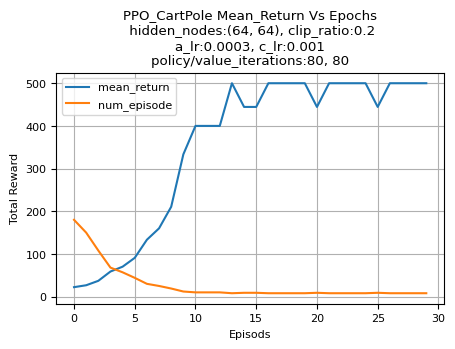

hidden_nodes:(64, 64), clip_ratio:0.2  
a_lr:0.0003,c_lr:0.001  
policy/value_iterations:80,80  
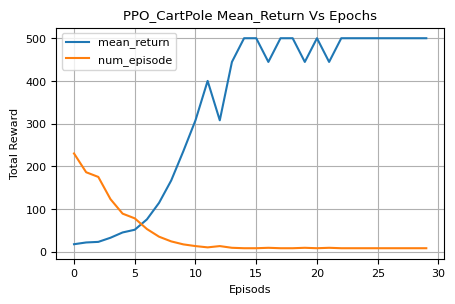

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="PPO")

/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


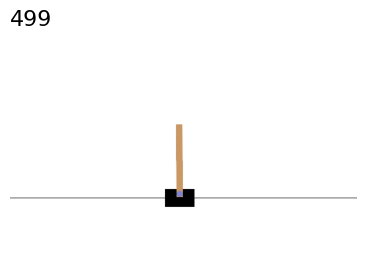

In [ ]:
state = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    state = state.reshape(1, -1)
    _, action = sample_action(state)
    state, reward, done, info = env_v.step(action[0].numpy())
    if done or cnt > 500:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='PPO')

/content/gdrive/MyDrive/Colab Notebooks/video/PPO-episode-0.mp4


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
show_video(path=path,name_prefix='PPO')

/content/gdrive/MyDrive/Colab Notebooks/video/PPO-episode-0.mp4
